# 🏗️ 04 — Analisi Esplorativa dei Dati CUP

Questo notebook esplora i dataset aggregati per **CUP** (Codice Unico di Progetto) degli aiuti di stato italiani (2014–2025).

Il CUP è l'identificativo univoco assegnato a ogni progetto di investimento pubblico in Italia, e consente di tracciare i progetti attraverso anni e beneficiari diversi.

**Obiettivi:**
1. Profiling dei dati: dimensioni, colonne, tipi, valori mancanti
2. Verifica di consistenza e compatibilità STATA
3. Distribuzione temporale dei record
4. Analisi finanziaria (importi nominali, elemento di aiuto)
5. Distribuzione geografica e settoriale
6. Analisi dei beneficiari e tipologie
7. Analisi dei CUP: unicità, duplicati, progetti multi-anno
8. Strumenti di aiuto e obiettivi

## 1. Setup e Caricamento Dati

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Stile grafici
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path('../data/cup_only')
YEARS = list(range(2014, 2026))

print('Setup completato ✓')

Setup completato ✓


In [2]:
# Caricamento di tutti i file CUP annuali
frames = []
for year in YEARS:
    filepath = DATA_DIR / f'aggregated_cup_{year}.csv'
    if not filepath.exists():
        print(f'  ⚠ File non trovato: {filepath.name}')
        continue
    
    print(f'Caricamento {year}...', end=' ')
    chunks = []
    for chunk in pd.read_csv(filepath, chunksize=100_000, low_memory=False):
        chunks.append(chunk)
    df_year = pd.concat(chunks, ignore_index=True)
    print(f'{len(df_year):>12,} righe')
    frames.append(df_year)

df = pd.concat(frames, ignore_index=True)
del frames

print(f'\n✅ Totale: {len(df):,} righe caricate')

Caricamento 2014...       15,434 righe
Caricamento 2015...        2,106 righe
Caricamento 2016...        8,132 righe
Caricamento 2017...      181,968 righe
Caricamento 2018...      525,825 righe
Caricamento 2019...      284,698 righe
Caricamento 2020...      654,762 righe
Caricamento 2021...      573,143 righe
Caricamento 2022...      522,647 righe
Caricamento 2023...      768,756 righe
Caricamento 2024...      597,320 righe
Caricamento 2025...      566,523 righe

✅ Totale: 4,701,314 righe caricate


## 2. Profiling dei Dati

In [3]:
# Panoramica delle colonne
print('=== INFO DATASET CUP ===')
print(f'Righe totali:   {len(df):>12,}')
print(f'Colonne:        {len(df.columns):>12}')
print(f'Memoria (MB):   {df.memory_usage(deep=True).sum() / 1e6:>12,.1f}')
print()

# Tipi e valori mancanti
info_df = pd.DataFrame({
    'Tipo': df.dtypes,
    'Non-Null': df.notna().sum(),
    'Null (%)': (df.isna().sum() / len(df) * 100).round(2),
    'Unici': df.nunique()
})
info_df

=== INFO DATASET CUP ===
Righe totali:      4,701,314
Colonne:                  21
Memoria (MB):        5,712.1



,Tipo,Non-Null,Null (%),Unici
CAR,int64,4701314,0.00,13245
TITOLO_MISURA,str,4701314,0.00,10756
DES_TIPO_MISURA,str,4701314,0.00,2
TITOLO_PROGETTO,str,4701307,0.00,772023
DESCRIZIONE_PROGETTO,str,4701310,0.00,758478
DATA_CONCESSIONE,str,4701314,0.00,3450
CUP,str,4701314,0.00,1816649
DENOMINAZIONE_BENEFICIARIO,str,4701314,0.00,1740822
CODICE_FISCALE_BENEFICIARIO,str,4701314,0.00,1768625
DES_TIPO_BENEFICIARIO,str,4701314,0.00,3


In [4]:
# Prime righe del dataset
df.head(3)

,CAR,TITOLO_MISURA,DES_TIPO_MISURA,TITOLO_PROGETTO,DESCRIZIONE_PROGETTO,DATA_CONCESSIONE,CUP,DENOMINAZIONE_BENEFICIARIO,CODICE_FISCALE_BENEFICIARIO,DES_TIPO_BENEFICIARIO,...,FILE_SOURCE,COR,ANNO,IMPORTO_NOMINALE_TOTALE,ELEMENTO_DI_AIUTO_TOTALE,NUM_COMPONENTI,NUM_STRUMENTI,COD_STRUMENTI,SETTORI_ATTIVITA,OBIETTIVO
0,201,Zone Franche Urbane dell’Obiettivo Convergenza...,Regime di aiuti,Agevolazioni fiscali e contributive per la ZFU...,Concessione di agevolazioni sotto forma di ese...,2014-06-30+02:00,B59D14021910001,"""DE.PO.-COSTRUZIONI MECCANICHE E PRODOTTI INDU...",00092260736,PMI,...,OpenData_Aiuti_2014_06.xml,3776,2014,18067.21,18067.21,1,1,16,C.28.2,Sviluppo regionale o locale
1,201,Zone Franche Urbane dell’Obiettivo Convergenza...,Regime di aiuti,Agevolazioni fiscali e contributive per la ZFU...,Concessione di agevolazioni sotto forma di ese...,2014-04-17+02:00,B88G14009160001,SULCIS EXPLORER DI ZOBOLI HUBERT,ZBLHRT74H21B745H,PMI,...,OpenData_Aiuti_2014_04.xml,21499,2014,28432.36,28432.36,1,1,16,N.79.9,Sviluppo regionale o locale
2,201,Zone Franche Urbane dell’Obiettivo Convergenza...,Regime di aiuti,Agevolazioni fiscali e contributive per la ZFU...,Concessione di agevolazioni sotto forma di ese...,2014-06-16+02:00,B49D14009580001,MARE AZZURRO SERVICE S.R.L.,02866800838,PMI,...,OpenData_Aiuti_2014_06.xml,22077,2014,0.00,0.00,1,1,16,G.46.3,Sviluppo regionale o locale


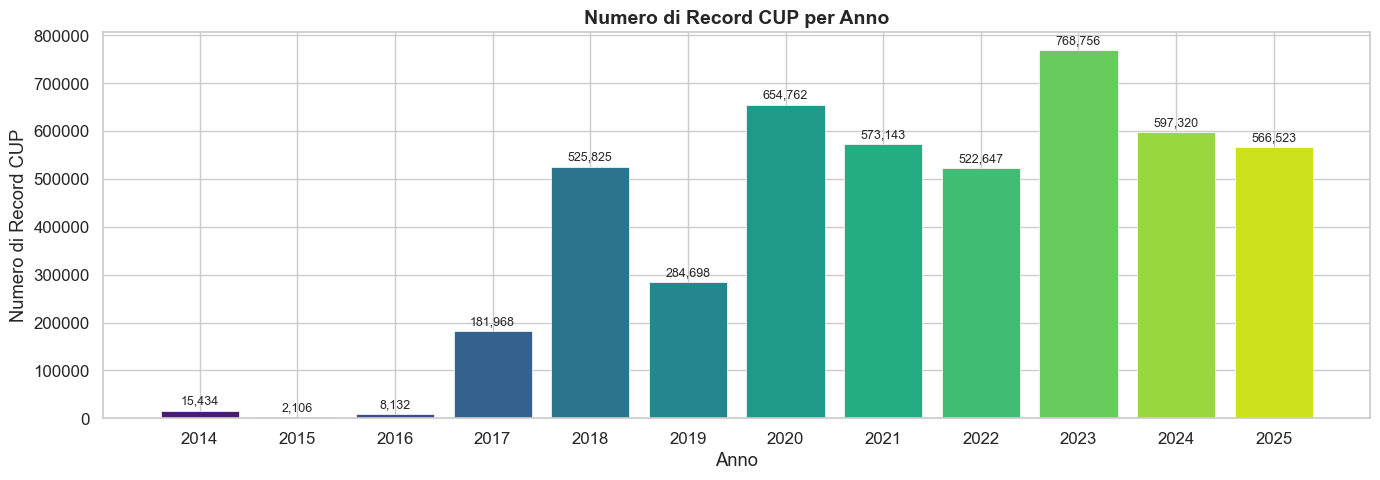

In [5]:
# Conteggio righe per anno
rows_per_year = df.groupby('ANNO').size().reset_index(name='num_righe')

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(rows_per_year['ANNO'], rows_per_year['num_righe'],
              color=sns.color_palette('viridis', len(rows_per_year)), edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, rows_per_year['num_righe']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(rows_per_year['num_righe'])*0.01,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Anno')
ax.set_ylabel('Numero di Record CUP')
ax.set_title('Numero di Record CUP per Anno', fontsize=14, fontweight='bold')
ax.set_xticks(rows_per_year['ANNO'])
plt.tight_layout()
plt.show()

## 3. Verifica di Consistenza e Compatibilità STATA

STATA impone vincoli specifici che possono causare problemi in fase di importazione:
- **Stringhe**: il tipo `str` supporta al massimo **2.045 caratteri** (oltre serve `strL`, disponibile da STATA 13+)
- **Encoding**: STATA gestisce nativamente ASCII/Latin-1; caratteri UTF-8 multi-byte possono causare troncamenti
- **Nomi colonne**: massimo **32 caratteri**, solo alfanumerici e underscore
- **Delimitatori interni**: virgole o apici nei campi possono rompere l'import CSV
- **Date**: formati non standard (es. con timezone `+02:00`) non vengono parsati
- **Valori numerici**: precisione `float` STATA è ~7 cifre significative (`double` ~15)

In [6]:
print('=== 3.1 NOMI COLONNE ===')
print(f'Numero colonne: {len(df.columns)}')

problemi_nomi = []
for col in df.columns:
    issues = []
    if len(col) > 32:
        issues.append(f'troppo lungo ({len(col)} chars, max 32)')
    if not col.replace('_', '').isalnum():
        issues.append('contiene caratteri non alfanumerici')
    if col[0].isdigit():
        issues.append('inizia con un numero')
    if issues:
        problemi_nomi.append((col, ', '.join(issues)))

if problemi_nomi:
    print('\n⚠ Colonne con problemi per STATA:')
    for col, issue in problemi_nomi:
        print(f'  - "{col}": {issue}')
else:
    print('✅ Tutti i nomi colonna sono compatibili con STATA')

=== 3.1 NOMI COLONNE ===
Numero colonne: 21
✅ Tutti i nomi colonna sono compatibili con STATA


In [7]:
print('=== 3.2 LUNGHEZZA STRINGHE (limite STATA str: 2.045 chars) ===\n')

str_cols = df.select_dtypes(include='object').columns
for col in str_cols:
    lengths = df[col].dropna().astype(str).str.len()
    max_len = lengths.max()
    over_limit = (lengths > 2045).sum()
    
    status = '⚠' if over_limit > 0 else '✅'
    print(f'{status} {col:40s} | max: {max_len:>6,} chars | >2045: {over_limit:>8,} record')

    if over_limit > 0:
        print(f'   → Richiede tipo strL in STATA 13+ oppure troncamento')

=== 3.2 LUNGHEZZA STRINGHE (limite STATA str: 2.045 chars) ===

✅ TITOLO_MISURA                            | max:    255 chars | >2045:        0 record
✅ DES_TIPO_MISURA                          | max:     15 chars | >2045:        0 record
✅ TITOLO_PROGETTO                          | max:    445 chars | >2045:        0 record
✅ DESCRIZIONE_PROGETTO                     | max:  1,300 chars | >2045:        0 record
✅ DATA_CONCESSIONE                         | max:     16 chars | >2045:        0 record
✅ CUP                                      | max:     15 chars | >2045:        0 record
✅ DENOMINAZIONE_BENEFICIARIO               | max:    390 chars | >2045:        0 record
✅ CODICE_FISCALE_BENEFICIARIO              | max:     19 chars | >2045:        0 record
✅ DES_TIPO_BENEFICIARIO                    | max:     14 chars | >2045:        0 record
✅ REGIONE_BENEFICIARIO                     | max:    491 chars | >2045:        0 record
✅ FILE_SOURCE                              | max:     30

In [8]:
# Record con SETTORI_ATTIVITA più lunghi (oltre il limite STATA di 2.045 chars)
sett_len = df['SETTORI_ATTIVITA'].dropna().astype(str).str.len()
top_long = sett_len.nlargest(10)

print(f'=== TOP 10 RECORD CON SETTORI_ATTIVITA PIÙ LUNGHI ===\n')
print(f'{"#":>3} {"Lunghezza":>10}   {"Anteprima (primi 120 chars)":<120}')
print('-' * 140)

for rank, (idx, length) in enumerate(top_long.items(), 1):
    preview = str(df.loc[idx, 'SETTORI_ATTIVITA'])[:120]
    anno = df.loc[idx, 'ANNO']
    cup = df.loc[idx, 'CUP']
    print(f'{rank:>3} {length:>10,}   [{anno}] CUP={cup} | {preview}...')

print(f'\n📊 Statistiche lunghezza SETTORI_ATTIVITA:')
print(f'   Media: {sett_len.mean():.1f} chars')
print(f'   Mediana: {sett_len.median():.0f} chars')
print(f'   95° percentile: {sett_len.quantile(0.95):.0f} chars')
print(f'   99° percentile: {sett_len.quantile(0.99):.0f} chars')
print(f'   Max: {sett_len.max():,} chars')
print(f'   Record > 2.045 chars: {(sett_len > 2045).sum():,} ({(sett_len > 2045).mean()*100:.3f}%)')

=== TOP 10 RECORD CON SETTORI_ATTIVITA PIÙ LUNGHI ===

  #  Lunghezza   Anteprima (primi 120 chars)                                                                                             
--------------------------------------------------------------------------------------------------------------------------------------------
  1      5,517   [2018] CUP=J97H18000300006 | A.01.0, A.01.1, A.01.2, A.01.3, A.01.4, A.01.5, A.01.6, A.01.7, A.02.0, A.02.1, A.02.2, A.02.3, A.02.4, A.03.0, A.03.1, ...
  2      2,845   [2025] CUP=I79J25000370003 | (NACE 2.1) A.01, A.01.1, A.01.2, A.01.3, A.01.4, A.01.5, A.01.6, A.01.7, A.02, A.02.1, A.02.2, A.02.3, A.02.4, A.03, A.0...
  3      2,827   [2025] CUP=F57G25000140006 | (NACE 2.1) A.01, A.01.1, A.01.2, A.01.3, A.01.4, A.01.5, A.01.6, A.01.7, A.02, A.02.1, A.02.2, A.02.3, A.02.4, A.03, A.0...
  4      2,827   [2025] CUP=E48C25000550001 | (NACE 2.1) A.01, A.01.1, A.01.2, A.01.3, A.01.4, A.01.5, A.01.6, A.01.7, A.02, A.02.1, A.02.2, A.02.3, A.02.4,

In [9]:
print('=== 3.3 ENCODING: CARATTERI NON-ASCII ===\n')

for col in str_cols:
    serie = df[col].dropna().astype(str)
    # Conta record con caratteri non-ASCII (potenziali problemi Latin-1)
    non_ascii_mask = serie.str.contains(r'[^\x00-\x7F]', regex=True, na=False)
    n_non_ascii = non_ascii_mask.sum()
    
    if n_non_ascii > 0:
        pct = n_non_ascii / len(serie) * 100
        print(f'⚠ {col:40s} | {n_non_ascii:>10,} record con caratteri non-ASCII ({pct:.2f}%)')
        # Mostra alcuni esempi di caratteri problematici
        sample_vals = serie[non_ascii_mask].head(3)
        for val in sample_vals:
            # Estrai solo i caratteri non-ASCII
            non_ascii_chars = set(c for c in val if ord(c) > 127)
            print(f'   Esempio chars: {non_ascii_chars}')
            break
    else:
        print(f'✅ {col:40s} | solo ASCII')

=== 3.3 ENCODING: CARATTERI NON-ASCII ===

⚠ TITOLO_MISURA                            |  1,195,960 record con caratteri non-ASCII (25.44%)
   Esempio chars: {'é', '’'}
✅ DES_TIPO_MISURA                          | solo ASCII
⚠ TITOLO_PROGETTO                          |    366,357 record con caratteri non-ASCII (7.79%)
   Esempio chars: {'â', '¿'}
⚠ DESCRIZIONE_PROGETTO                     |  1,061,719 record con caratteri non-ASCII (22.58%)
   Esempio chars: {'â', '¿'}
✅ DATA_CONCESSIONE                         | solo ASCII
✅ CUP                                      | solo ASCII
⚠ DENOMINAZIONE_BENEFICIARIO               |      5,097 record con caratteri non-ASCII (0.11%)
   Esempio chars: {'Ì'}
⚠ CODICE_FISCALE_BENEFICIARIO              |          1 record con caratteri non-ASCII (0.00%)
   Esempio chars: {'¿'}
✅ DES_TIPO_BENEFICIARIO                    | solo ASCII
⚠ REGIONE_BENEFICIARIO                     |     21,252 record con caratteri non-ASCII (0.45%)
   Esempio chars: {'ü'}
✅ 

In [10]:
print('=== 3.4 FORMATO DATE (DATA_CONCESSIONE) ===\n')

date_col = df['DATA_CONCESSIONE'].dropna().astype(str)

# Identifica i formati presenti
has_timezone = date_col.str.contains(r'[+-]\d{2}:\d{2}$', regex=True, na=False)
pure_date = date_col.str.match(r'^\d{4}-\d{2}-\d{2}$', na=False)
other_format = ~has_timezone & ~pure_date

print(f'Formato YYYY-MM-DD (puro):         {pure_date.sum():>10,} ({pure_date.mean()*100:.1f}%)')
print(f'Formato con timezone (+XX:00):      {has_timezone.sum():>10,} ({has_timezone.mean()*100:.1f}%)')
print(f'Altro formato:                      {other_format.sum():>10,} ({other_format.mean()*100:.1f}%)')

if has_timezone.any():
    print(f'\n⚠ STATA non gestisce il suffisso timezone. Esempi:')
    for val in date_col[has_timezone].head(3):
        print(f'   "{val}" → rimuovere il suffisso timezone prima dell\'import')

if other_format.any():
    print(f'\n⚠ Formati non standard trovati:')
    for val in date_col[other_format].unique()[:5]:
        print(f'   "{val}"')

=== 3.4 FORMATO DATE (DATA_CONCESSIONE) ===

Formato YYYY-MM-DD (puro):          1,174,500 (25.0%)
Formato con timezone (+XX:00):       3,526,814 (75.0%)
Altro formato:                               0 (0.0%)

⚠ STATA non gestisce il suffisso timezone. Esempi:
   "2014-06-30+02:00" → rimuovere il suffisso timezone prima dell'import
   "2014-04-17+02:00" → rimuovere il suffisso timezone prima dell'import
   "2014-06-16+02:00" → rimuovere il suffisso timezone prima dell'import


In [11]:
print('=== 3.5 DELIMITATORI INTERNI NEI CAMPI STRINGA ===\n')

for col in str_cols:
    serie = df[col].dropna().astype(str)
    
    has_comma = serie.str.contains(',', na=False).sum()
    has_semicolon = serie.str.contains(';', na=False).sum()
    has_quotes = serie.str.contains('"', na=False).sum()
    has_newline = serie.str.contains(r'\n|\r', regex=True, na=False).sum()
    
    issues = []
    if has_comma > 0:
        issues.append(f'virgole: {has_comma:,}')
    if has_quotes > 0:
        issues.append(f'doppi apici: {has_quotes:,}')
    if has_newline > 0:
        issues.append(f'a-capo: {has_newline:,}')
    
    if issues:
        print(f'⚠ {col:40s} | {" | ".join(issues)}')
    else:
        print(f'✅ {col:40s} | nessun delimitatore interno')

=== 3.5 DELIMITATORI INTERNI NEI CAMPI STRINGA ===

⚠ TITOLO_MISURA                            | virgole: 700,629 | doppi apici: 181,198
✅ DES_TIPO_MISURA                          | nessun delimitatore interno
⚠ TITOLO_PROGETTO                          | virgole: 240,540 | doppi apici: 49,899 | a-capo: 21,221
⚠ DESCRIZIONE_PROGETTO                     | virgole: 794,509 | doppi apici: 207,760 | a-capo: 138,233
✅ DATA_CONCESSIONE                         | nessun delimitatore interno
✅ CUP                                      | nessun delimitatore interno
⚠ DENOMINAZIONE_BENEFICIARIO               | virgole: 35,763 | doppi apici: 115,900 | a-capo: 217
✅ CODICE_FISCALE_BENEFICIARIO              | nessun delimitatore interno
✅ DES_TIPO_BENEFICIARIO                    | nessun delimitatore interno
⚠ REGIONE_BENEFICIARIO                     | virgole: 22,870
✅ FILE_SOURCE                              | nessun delimitatore interno
✅ COD_STRUMENTI                            | nessun delimitato

In [12]:
print('=== 3.6 VALORI NUMERICI: CONSISTENZA E PRECISIONE ===\n')

num_cols = ['IMPORTO_NOMINALE_TOTALE', 'ELEMENTO_DI_AIUTO_TOTALE', 'NUM_COMPONENTI', 'NUM_STRUMENTI']

for col in num_cols:
    serie = pd.to_numeric(df[col], errors='coerce')
    n_non_numeric = df[col].notna().sum() - serie.notna().sum()
    n_negative = (serie < 0).sum()
    max_val = serie.max()
    
    issues = []
    if n_non_numeric > 0:
        issues.append(f'{n_non_numeric:,} valori non numerici')
    if n_negative > 0:
        issues.append(f'{n_negative:,} valori negativi')
    # STATA float ha ~7 cifre significative; double ~15
    if max_val and max_val > 1e15:
        issues.append(f'max={max_val:.2e}, possibile perdita precisione float STATA')
    
    status = '⚠' if issues else '✅'
    print(f'{status} {col:35s} | min: {serie.min():>15,.2f} | max: {serie.max():>15,.2f}')
    if issues:
        for i in issues:
            print(f'   → {i}')

print(f'\n💡 Nota: per preservare la precisione degli importi in STATA, usare il tipo `double`')

=== 3.6 VALORI NUMERICI: CONSISTENZA E PRECISIONE ===

✅ IMPORTO_NOMINALE_TOTALE             | min:            0.00 | max: 2,500,016,000.00
✅ ELEMENTO_DI_AIUTO_TOTALE            | min:            0.00 | max: 2,063,178,843.50
✅ NUM_COMPONENTI                      | min:            1.00 | max:           12.00
✅ NUM_STRUMENTI                       | min:            0.00 | max:           19.00

💡 Nota: per preservare la precisione degli importi in STATA, usare il tipo `double`


In [13]:
print('=== 3.7 FORMATO CUP: VALIDAZIONE STRUTTURALE ===\n')

cup_serie = df['CUP'].dropna().astype(str)

# Il CUP ha un formato standard: 15 caratteri alfanumerici (es. B67B20043490009)
cup_len = cup_serie.str.len()
print(f'Lunghezza CUP — min: {cup_len.min()}, max: {cup_len.max()}, moda: {cup_len.mode().iloc[0]}')

# Verifica formato standard (15 chars alfanumerici)
valid_cup = cup_serie.str.match(r'^[A-Z0-9]{15}$', na=False)
invalid_cup = ~valid_cup
n_invalid = invalid_cup.sum()

if n_invalid > 0:
    pct = n_invalid / len(cup_serie) * 100
    print(f'\n⚠ {n_invalid:,} CUP con formato non standard ({pct:.2f}%)')
    print('Esempi:')
    for val in cup_serie[invalid_cup].head(5):
        print(f'   "{val}" (len={len(val)})')
else:
    print(f'\n✅ Tutti i {len(cup_serie):,} CUP hanno formato standard (15 chars alfanumerici)')

=== 3.7 FORMATO CUP: VALIDAZIONE STRUTTURALE ===

Lunghezza CUP — min: 1, max: 15, moda: 15

⚠ 11,171 CUP con formato non standard (0.24%)
Esempi:
   "0000" (len=4)
   "0000" (len=4)
   "0000" (len=4)
   "0000" (len=4)
   "0000" (len=4)


In [14]:
print('=== 3.8 RIEPILOGO CONSISTENZA PER STATA ===\n')

print('Raccomandazioni per l\'import in STATA:')
print('  1. Rimuovere il suffisso timezone da DATA_CONCESSIONE (es. "+02:00")')
print('  2. Usare `import delimited` con opzione `bindquote(strict)` per gestire le virgole nei campi')
print('  3. Campi con testo lungo: usare STATA 13+ per supporto strL, oppure troncare')
print('  4. Importare gli importi come `double` per evitare perdita di precisione')
print('  5. Se si usa encoding UTF-8, specificare `encoding(utf-8)` nell\'import')
print('  6. Verificare i CUP non standard prima di usarli come chiave di join')

=== 3.8 RIEPILOGO CONSISTENZA PER STATA ===

Raccomandazioni per l'import in STATA:
  1. Rimuovere il suffisso timezone da DATA_CONCESSIONE (es. "+02:00")
  2. Usare `import delimited` con opzione `bindquote(strict)` per gestire le virgole nei campi
  3. Campi con testo lungo: usare STATA 13+ per supporto strL, oppure troncare
  4. Importare gli importi come `double` per evitare perdita di precisione
  5. Se si usa encoding UTF-8, specificare `encoding(utf-8)` nell'import
  6. Verificare i CUP non standard prima di usarli come chiave di join


## 4. Analisi Finanziaria

In [15]:
# Conversione colonne numeriche
df['IMPORTO_NOMINALE_TOTALE'] = pd.to_numeric(df['IMPORTO_NOMINALE_TOTALE'], errors='coerce')
df['ELEMENTO_DI_AIUTO_TOTALE'] = pd.to_numeric(df['ELEMENTO_DI_AIUTO_TOTALE'], errors='coerce')
df['NUM_COMPONENTI'] = pd.to_numeric(df['NUM_COMPONENTI'], errors='coerce')
df['NUM_STRUMENTI'] = pd.to_numeric(df['NUM_STRUMENTI'], errors='coerce')

# Statistiche descrittive degli importi
importi_stats = df[['IMPORTO_NOMINALE_TOTALE', 'ELEMENTO_DI_AIUTO_TOTALE']].describe()
importi_stats.loc['sum'] = df[['IMPORTO_NOMINALE_TOTALE', 'ELEMENTO_DI_AIUTO_TOTALE']].sum()

# Formattazione
for col in importi_stats.columns:
    importi_stats[col] = importi_stats[col].apply(lambda x: f'€ {x:,.2f}')

importi_stats

,IMPORTO_NOMINALE_TOTALE,ELEMENTO_DI_AIUTO_TOTALE
count,"€ 4,701,314.00","€ 4,701,314.00"
mean,"€ 51,428.36","€ 17,543.88"
std,"€ 1,790,323.29","€ 1,206,093.32"
min,€ 0.00,€ 0.00
25%,"€ 1,475.26",€ 945.80
50%,"€ 5,000.00","€ 2,265.00"
75%,"€ 28,800.00","€ 6,960.43"
max,"€ 2,500,016,000.00","€ 2,063,178,843.50"
sum,"€ 241,780,862,021.81","€ 82,479,289,431.33"


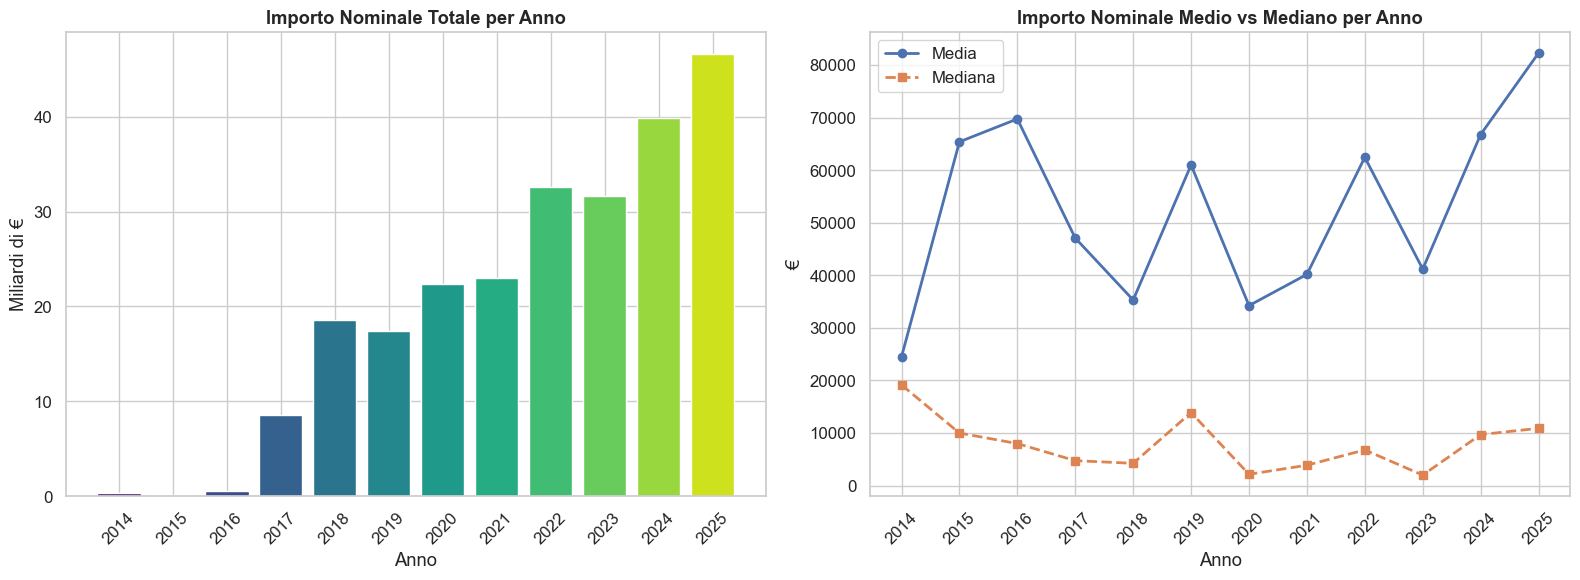

In [16]:
# Importo totale e medio per anno
importi_anno = df.groupby('ANNO').agg(
    importo_totale=('IMPORTO_NOMINALE_TOTALE', 'sum'),
    importo_medio=('IMPORTO_NOMINALE_TOTALE', 'mean'),
    importo_mediano=('IMPORTO_NOMINALE_TOTALE', 'median'),
    elemento_totale=('ELEMENTO_DI_AIUTO_TOTALE', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Importo totale per anno
axes[0].bar(importi_anno['ANNO'], importi_anno['importo_totale'] / 1e9,
            color=sns.color_palette('viridis', len(importi_anno)), edgecolor='white')
axes[0].set_title('Importo Nominale Totale per Anno', fontweight='bold')
axes[0].set_xlabel('Anno')
axes[0].set_ylabel('Miliardi di €')
axes[0].set_xticks(importi_anno['ANNO'])
axes[0].tick_params(axis='x', rotation=45)

# Importo medio vs mediano
axes[1].plot(importi_anno['ANNO'], importi_anno['importo_medio'], 'o-', label='Media', linewidth=2)
axes[1].plot(importi_anno['ANNO'], importi_anno['importo_mediano'], 's--', label='Mediana', linewidth=2)
axes[1].set_title('Importo Nominale Medio vs Mediano per Anno', fontweight='bold')
axes[1].set_xlabel('Anno')
axes[1].set_ylabel('€')
axes[1].legend()
axes[1].set_xticks(importi_anno['ANNO'])
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

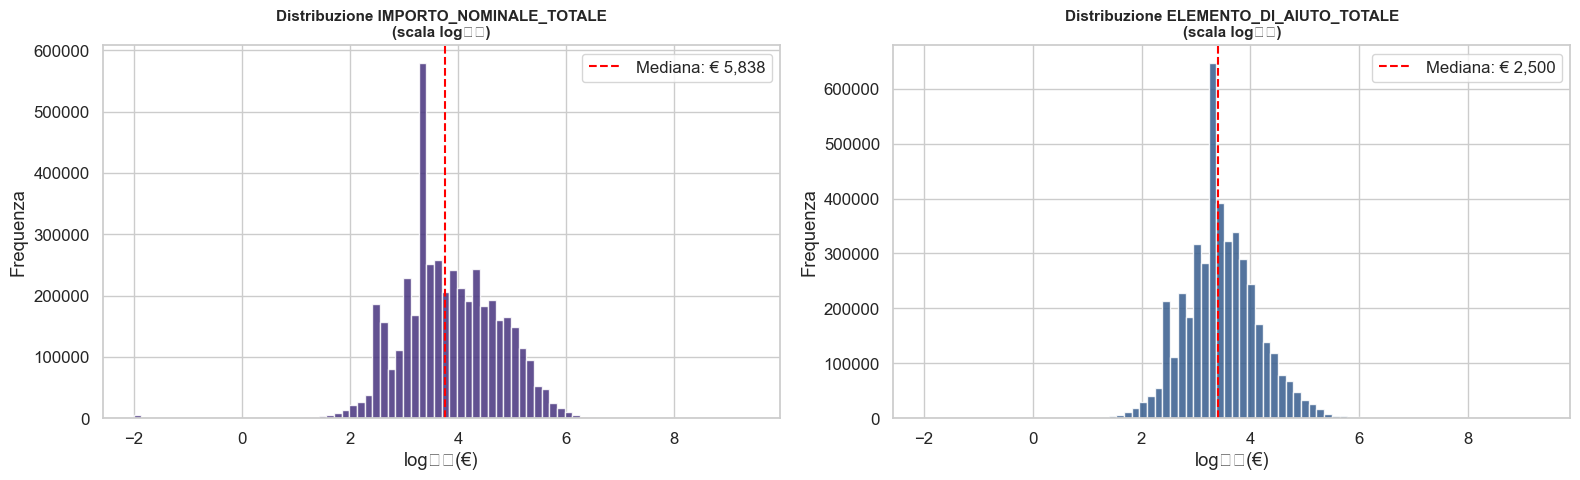

In [17]:
# Distribuzione degli importi (scala log)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx, col in enumerate(['IMPORTO_NOMINALE_TOTALE', 'ELEMENTO_DI_AIUTO_TOTALE']):
    data = df[col].dropna()
    data_pos = data[data > 0]
    
    axes[idx].hist(np.log10(data_pos), bins=80, color=sns.color_palette('viridis')[idx], 
                   edgecolor='white', alpha=0.85)
    axes[idx].axvline(np.log10(data_pos.median()), color='red', linestyle='--', 
                      label=f'Mediana: € {data_pos.median():,.0f}')
    axes[idx].set_title(f'Distribuzione {col}\n(scala log₁₀)', fontweight='bold', fontsize=11)
    axes[idx].set_xlabel('log₁₀(€)')
    axes[idx].set_ylabel('Frequenza')
    axes[idx].legend()

plt.tight_layout()
plt.show()

## 5. Distribuzione Geografica

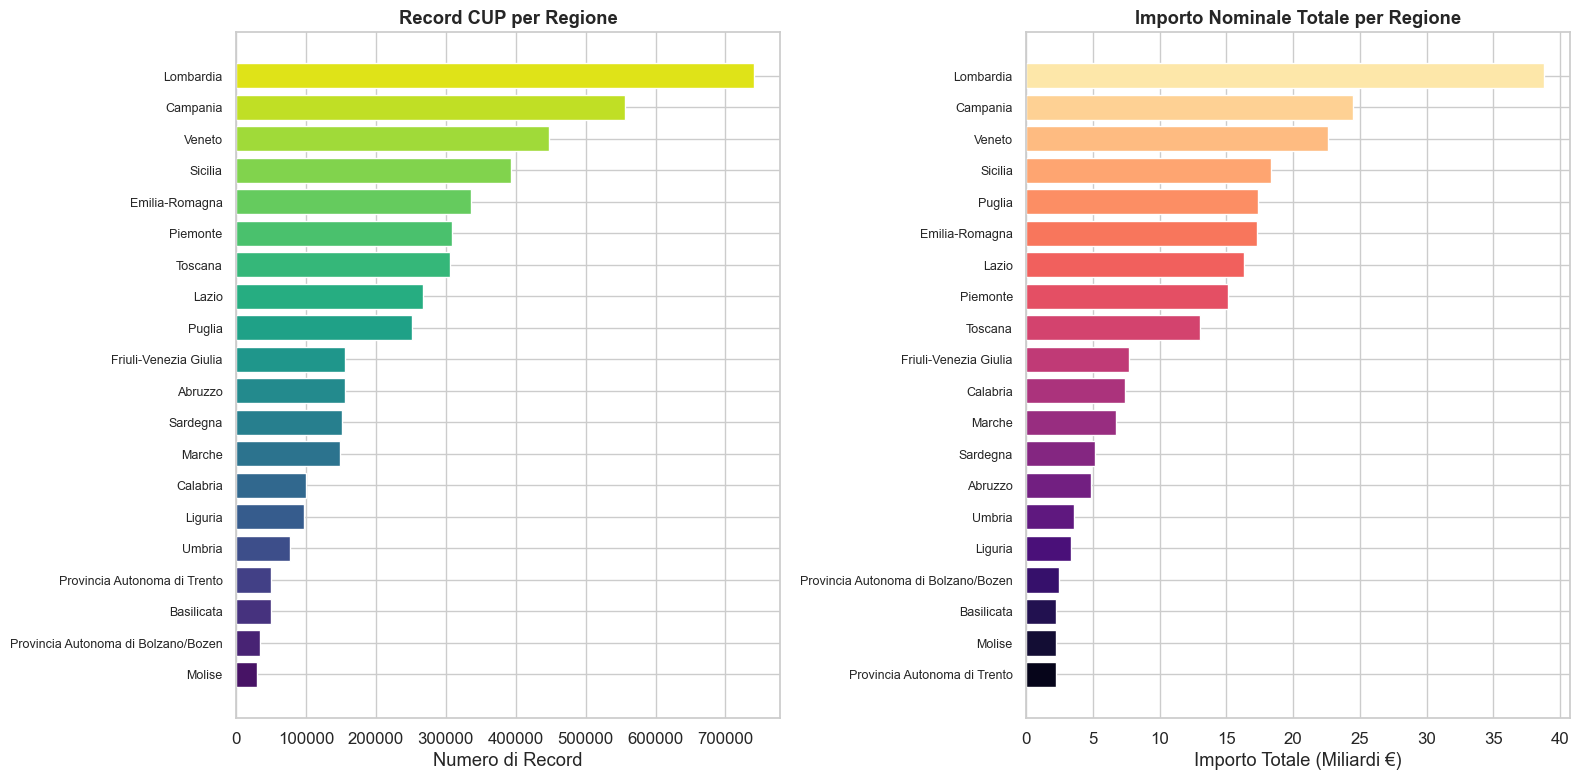

In [18]:
# Distribuzione regionale: numero di record e importo totale
regione_stats = df.groupby('REGIONE_BENEFICIARIO').agg(
    num_record=('CUP', 'count'),
    importo_totale=('IMPORTO_NOMINALE_TOTALE', 'sum'),
    importo_medio=('IMPORTO_NOMINALE_TOTALE', 'mean'),
    cup_unici=('CUP', 'nunique')
).sort_values('num_record', ascending=False)

# Filtra solo le 20 regioni italiane standard (esclude multi-regione e estero)
regioni_italiane = [
    'Lombardia', 'Lazio', 'Campania', 'Sicilia', 'Veneto', 'Emilia-Romagna',
    'Piemonte', 'Puglia', 'Toscana', 'Calabria', 'Sardegna', 'Liguria',
    'Marche', 'Abruzzo', 'Friuli-Venezia Giulia', 'Umbria', 'Basilicata',
    'Molise', "Valle d'Aosta", 'Trentino-Alto Adige',
    'Provincia Autonoma di Trento', 'Provincia Autonoma di Bolzano/Bozen'
]

reg_it = regione_stats[regione_stats.index.isin(regioni_italiane)].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Per numero di record
reg_sorted = reg_it.sort_values('num_record', ascending=True)
axes[0].barh(range(len(reg_sorted)), reg_sorted['num_record'],
             color=sns.color_palette('viridis', len(reg_sorted)))
axes[0].set_yticks(range(len(reg_sorted)))
axes[0].set_yticklabels(reg_sorted.index, fontsize=9)
axes[0].set_xlabel('Numero di Record')
axes[0].set_title('Record CUP per Regione', fontweight='bold')

# Per importo totale
reg_sorted_imp = reg_it.sort_values('importo_totale', ascending=True)
axes[1].barh(range(len(reg_sorted_imp)), reg_sorted_imp['importo_totale'] / 1e9,
             color=sns.color_palette('magma', len(reg_sorted_imp)))
axes[1].set_yticks(range(len(reg_sorted_imp)))
axes[1].set_yticklabels(reg_sorted_imp.index, fontsize=9)
axes[1].set_xlabel('Importo Totale (Miliardi €)')
axes[1].set_title('Importo Nominale Totale per Regione', fontweight='bold')

plt.tight_layout()
plt.show()

In [19]:
# Record multi-regione (beneficiari presenti in più regioni)
multi_regione = regione_stats[~regione_stats.index.isin(regioni_italiane)]
print(f'Record con regione multi-valore o estera: {multi_regione["num_record"].sum():,}')
print(f'Valori unici non-standard: {len(multi_regione)}')
print(f'\nTop 10 valori non-standard:')
display(multi_regione.head(10)[['num_record', 'importo_totale']])

Record con regione multi-valore o estera: 43,979
Valori unici non-standard: 483

Top 10 valori non-standard:


,num_record,importo_totale
REGIONE_BENEFICIARIO,,
Valle d'Aosta/Vallée d'Aoste,20958,6.873619e+08
"Lombardia, Piemonte",1621,3.812310e+08
"Campania, Lombardia",1393,3.048904e+08
"Campania, Lazio",1349,3.010530e+08
"Emilia-Romagna, Lombardia",1073,2.451634e+08
"Lombardia, Veneto",944,2.050270e+08
"Lazio, Lombardia",757,1.652874e+08
"Lombardia, Sicilia",579,1.336439e+08
"Friuli-Venezia Giulia, Veneto",574,3.001660e+08


## 6. Analisi Settoriale (ATECO)

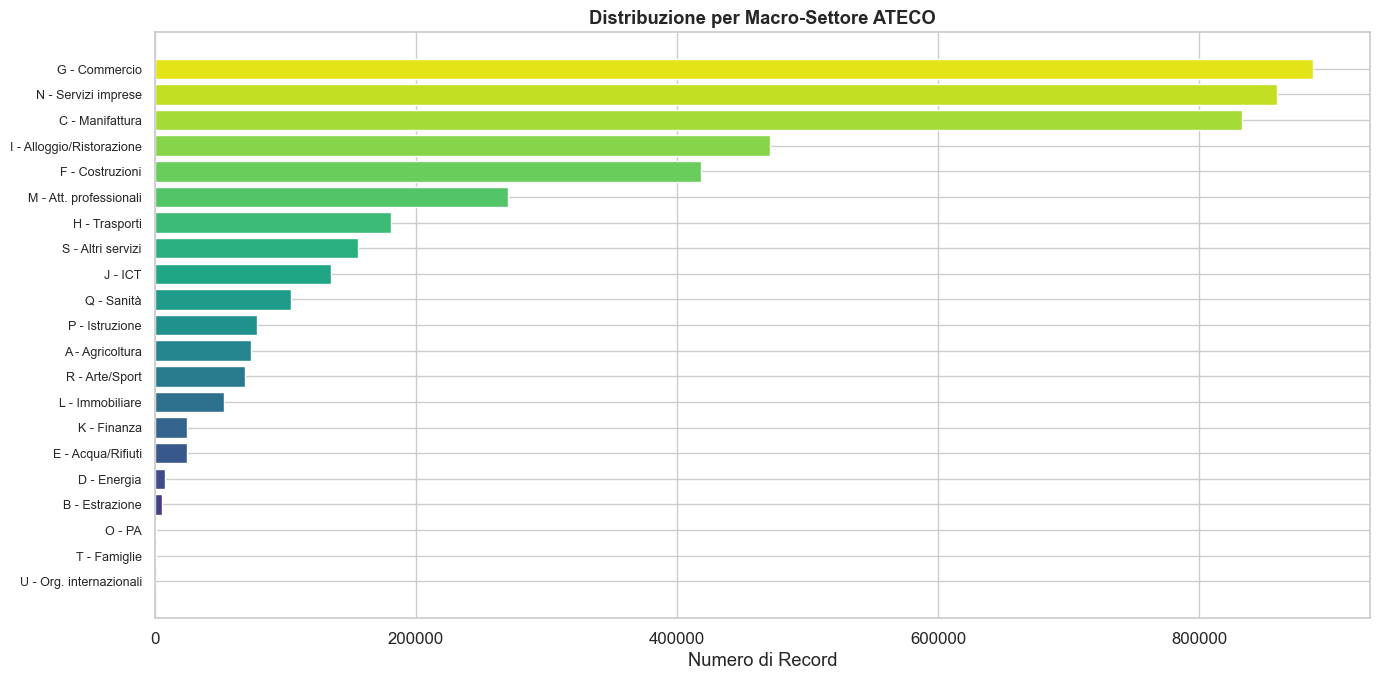

In [20]:
# Estrai la lettera macro-settore dal codice ATECO (es. "C.33.2" → "C")
df['SETTORE_MACRO'] = df['SETTORI_ATTIVITA'].astype(str).str.extract(r'([A-Z])', expand=False)

# Mapping ATECO sezioni
ateco_map = {
    'A': 'Agricoltura', 'B': 'Estrazione', 'C': 'Manifattura',
    'D': 'Energia', 'E': 'Acqua/Rifiuti', 'F': 'Costruzioni',
    'G': 'Commercio', 'H': 'Trasporti', 'I': 'Alloggio/Ristorazione',
    'J': 'ICT', 'K': 'Finanza', 'L': 'Immobiliare',
    'M': 'Att. professionali', 'N': 'Servizi imprese', 'O': 'PA',
    'P': 'Istruzione', 'Q': 'Sanità', 'R': 'Arte/Sport',
    'S': 'Altri servizi', 'T': 'Famiglie', 'U': 'Org. internazionali'
}

settore_counts = df['SETTORE_MACRO'].value_counts()
settore_counts.index = [f'{s} - {ateco_map.get(s, "?")}' for s in settore_counts.index]

fig, ax = plt.subplots(figsize=(14, 7))
settore_sorted = settore_counts.sort_values(ascending=True)
ax.barh(range(len(settore_sorted)), settore_sorted.values,
        color=sns.color_palette('viridis', len(settore_sorted)))
ax.set_yticks(range(len(settore_sorted)))
ax.set_yticklabels(settore_sorted.index, fontsize=9)
ax.set_xlabel('Numero di Record')
ax.set_title('Distribuzione per Macro-Settore ATECO', fontweight='bold')
plt.tight_layout()
plt.show()

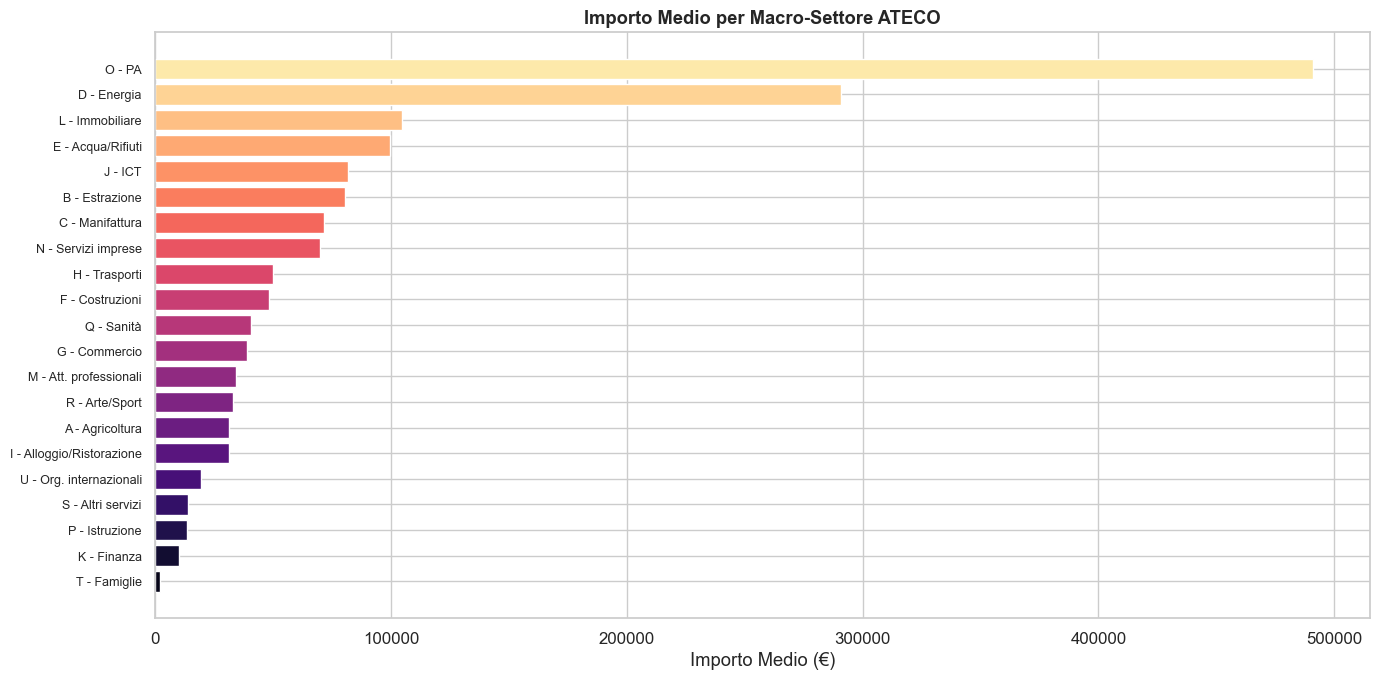

In [21]:
# Importo medio per macro-settore
settore_importi = df.groupby('SETTORE_MACRO').agg(
    num_record=('CUP', 'count'),
    importo_totale=('IMPORTO_NOMINALE_TOTALE', 'sum'),
    importo_medio=('IMPORTO_NOMINALE_TOTALE', 'mean'),
    importo_mediano=('IMPORTO_NOMINALE_TOTALE', 'median')
).sort_values('importo_medio', ascending=False)

settore_importi.index = [f'{s} - {ateco_map.get(s, "?")}' for s in settore_importi.index]

fig, ax = plt.subplots(figsize=(14, 7))
settore_imp_sorted = settore_importi.sort_values('importo_medio', ascending=True)
ax.barh(range(len(settore_imp_sorted)), settore_imp_sorted['importo_medio'],
        color=sns.color_palette('magma', len(settore_imp_sorted)))
ax.set_yticks(range(len(settore_imp_sorted)))
ax.set_yticklabels(settore_imp_sorted.index, fontsize=9)
ax.set_xlabel('Importo Medio (€)')
ax.set_title('Importo Medio per Macro-Settore ATECO', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Analisi dei Beneficiari

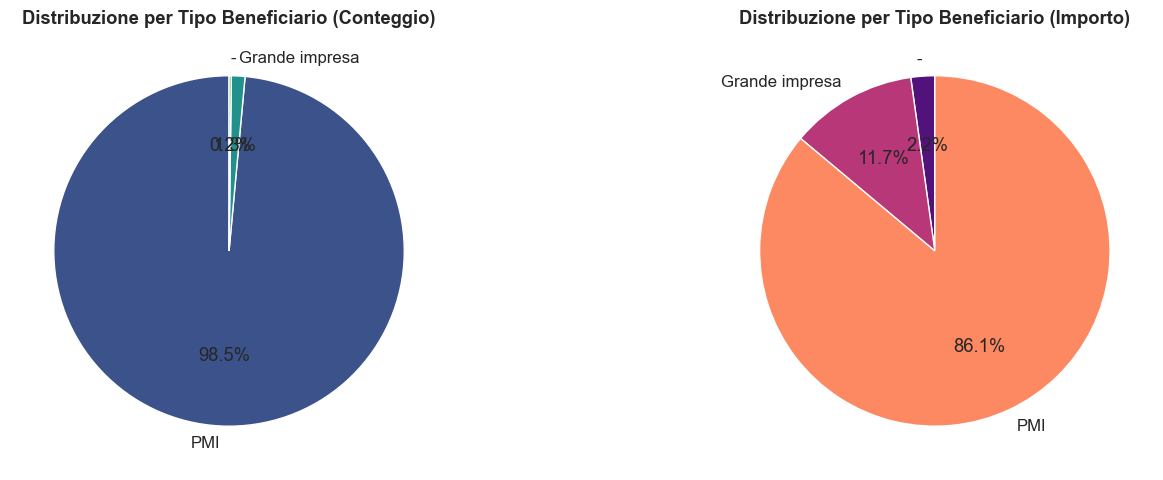

In [22]:
# Distribuzione per tipo beneficiario
tipo_ben = df['DES_TIPO_BENEFICIARIO'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Conteggio
axes[0].pie(tipo_ben, labels=tipo_ben.index, autopct='%1.1f%%', 
            colors=sns.color_palette('viridis', len(tipo_ben)), startangle=90)
axes[0].set_title('Distribuzione per Tipo Beneficiario (Conteggio)', fontweight='bold')

# Importo totale per tipo
tipo_importo = df.groupby('DES_TIPO_BENEFICIARIO')['IMPORTO_NOMINALE_TOTALE'].sum()
axes[1].pie(tipo_importo, labels=tipo_importo.index, autopct='%1.1f%%',
            colors=sns.color_palette('magma', len(tipo_importo)), startangle=90)
axes[1].set_title('Distribuzione per Tipo Beneficiario (Importo)', fontweight='bold')

plt.tight_layout()
plt.show()

In [23]:
# Top 20 beneficiari per numero di aiuti CUP
top_ben = (df.groupby('DENOMINAZIONE_BENEFICIARIO')
           .agg(num_aiuti=('CUP', 'count'),
                cup_unici=('CUP', 'nunique'),
                importo_totale=('IMPORTO_NOMINALE_TOTALE', 'sum'))
           .sort_values('num_aiuti', ascending=False)
           .head(20))

top_ben['importo_totale_fmt'] = top_ben['importo_totale'].apply(lambda x: f'€ {x:,.2f}')
display(top_ben[['num_aiuti', 'cup_unici', 'importo_totale_fmt']])

,num_aiuti,cup_unici,importo_totale_fmt
DENOMINAZIONE_BENEFICIARIO,,,
TELECOM ITALIA SPA,997,1,"€ 1,463,700.00"
OVS SPA,852,12,"€ 1,453,013.90"
VODAFONE ITALIA S.P.A.,524,11,"€ 63,093,303.82"
WIND TRE S.P.A.,441,1,"€ 216,800.00"
DIGITAL ROCK HOLDING S.P.A.,274,1,"€ 199,999.06"
SYSTEM HOUSE S.R.L.,268,5,"€ 842,063.57"
SOISY S.P.A.,266,2,"€ 187,380.42"
ALBA S.R.L.,257,110,"€ 15,692,672.51"
FUTURA S.R.L.,245,127,"€ 7,777,489.99"


## 8. Analisi dei CUP: Unicità e Progetti Multi-Anno

Il CUP è l'identificativo unico di progetto. Lo stesso CUP può comparire in più record (più beneficiari nello stesso progetto) o in anni diversi (progetti pluriennali).

In [24]:
# Statistiche di base sui CUP
n_record = len(df)
n_cup_unici = df['CUP'].nunique()
n_cup_null = df['CUP'].isna().sum()

print(f'Record totali:          {n_record:>12,}')
print(f'CUP unici:              {n_cup_unici:>12,}')
print(f'CUP mancanti (NaN):     {n_cup_null:>12,}')
print(f'Rapporto record/CUP:    {n_record / n_cup_unici:>12.2f}')
print(f'\nIn media, ogni CUP compare {n_record / n_cup_unici:.1f} volte nel dataset')

Record totali:             4,701,314
CUP unici:                 1,816,649
CUP mancanti (NaN):                0
Rapporto record/CUP:            2.59

In media, ogni CUP compare 2.6 volte nel dataset


Distribuzione occorrenze per CUP:
  CUP con 1 solo record:      1,757,066 (96.7%)
  CUP con 2-5 record:            41,089
  CUP con 6-10 record:            5,647
  CUP con 11-50 record:           9,939
  CUP con >50 record:             2,908
  Max occorrenze per un CUP:   1,250,164


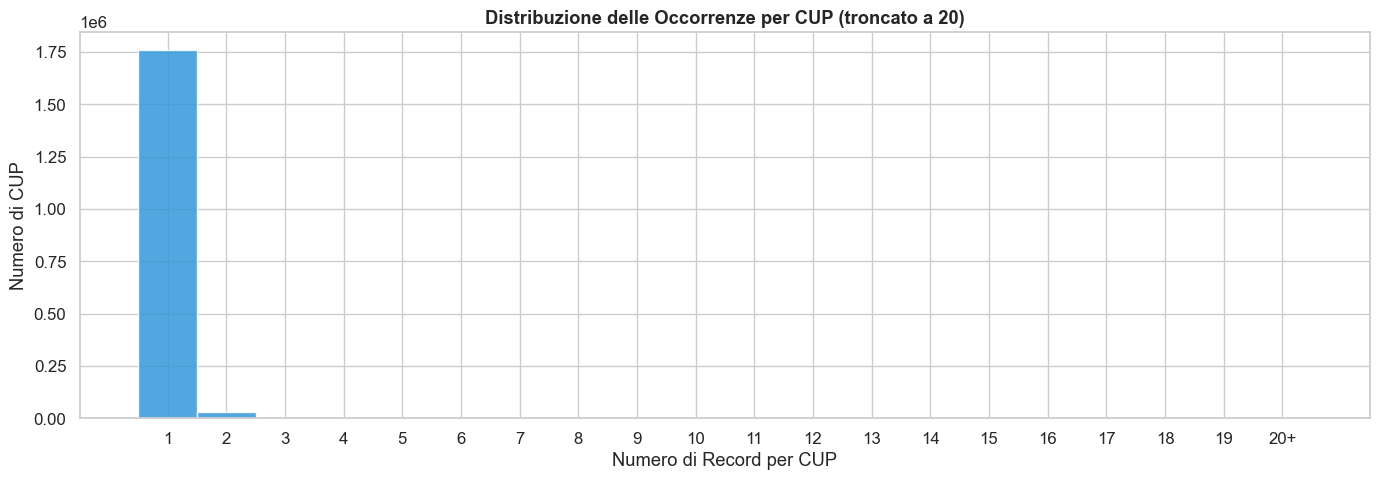

In [25]:
# Distribuzione delle occorrenze per CUP
cup_counts = df['CUP'].value_counts()

print('Distribuzione occorrenze per CUP:')
print(f'  CUP con 1 solo record:     {(cup_counts == 1).sum():>10,} ({(cup_counts == 1).mean()*100:.1f}%)')
print(f'  CUP con 2-5 record:        {((cup_counts >= 2) & (cup_counts <= 5)).sum():>10,}')
print(f'  CUP con 6-10 record:       {((cup_counts >= 6) & (cup_counts <= 10)).sum():>10,}')
print(f'  CUP con 11-50 record:      {((cup_counts >= 11) & (cup_counts <= 50)).sum():>10,}')
print(f'  CUP con >50 record:        {(cup_counts > 50).sum():>10,}')
print(f'  Max occorrenze per un CUP:  {cup_counts.max():>10,}')

fig, ax = plt.subplots(figsize=(14, 5))
cup_counts_clipped = cup_counts.clip(upper=20)
ax.hist(cup_counts_clipped, bins=range(1, 22), color='#3498db', edgecolor='white', alpha=0.85, align='left')
ax.set_xlabel('Numero di Record per CUP')
ax.set_ylabel('Numero di CUP')
ax.set_title('Distribuzione delle Occorrenze per CUP (troncato a 20)', fontweight='bold')
ax.set_xticks(range(1, 21))
ax.set_xticklabels([str(i) if i < 20 else '20+' for i in range(1, 21)])
plt.tight_layout()
plt.show()

In [26]:
# Progetti multi-anno: CUP che compaiono in anni diversi
cup_anni = df.groupby('CUP')['ANNO'].nunique()
cup_multi_anno = cup_anni[cup_anni > 1]

print(f'CUP presenti in più anni: {len(cup_multi_anno):,} ({len(cup_multi_anno)/n_cup_unici*100:.2f}% del totale)')
print(f'\nDistribuzione per numero di anni:')
for n_anni in sorted(cup_multi_anno.unique()):
    count = (cup_multi_anno == n_anni).sum()
    print(f'  {n_anni} anni: {count:>8,} CUP')

# Top CUP con più anni di copertura
if len(cup_multi_anno) > 0:
    top_multi = cup_multi_anno.sort_values(ascending=False).head(10)
    print(f'\nTop 10 CUP per copertura temporale:')
    for cup_code, n in top_multi.items():
        anni_list = sorted(df[df['CUP'] == cup_code]['ANNO'].unique())
        print(f'  {cup_code}: {n} anni ({anni_list[0]}–{anni_list[-1]})')

CUP presenti in più anni: 19,814 (1.09% del totale)

Distribuzione per numero di anni:
  2 anni:   16,588 CUP
  3 anni:    2,661 CUP
  4 anni:      473 CUP
  5 anni:       58 CUP
  6 anni:       15 CUP
  7 anni:        9 CUP
  8 anni:        7 CUP
  9 anni:        3 CUP

Top 10 CUP per copertura temporale:
  B56J13000770007: 9 anni (2017–2025)
  E48C16000160009: 9 anni (2017–2025)
  B58C96000000001: 9 anni (2017–2025)
  F83D17000490009: 8 anni (2018–2025)
  B18B17000040001: 8 anni (2018–2025)
  B75E18000030001: 8 anni (2018–2025)
  I56G17000260002: 8 anni (2017–2024)
  B11J17000120001: 8 anni (2018–2025)
  B61J15000010009: 8 anni (2018–2025)
  B37C18005210001: 8 anni (2018–2025)


=== PROGETTI MULTI-BENEFICIARIO (NUM_COMPONENTI) ===

Statistiche NUM_COMPONENTI:
  Media:    1.01
  Mediana:  1
  Max:      12

Record con NUM_COMPONENTI > 1: 31,766 (0.68%)


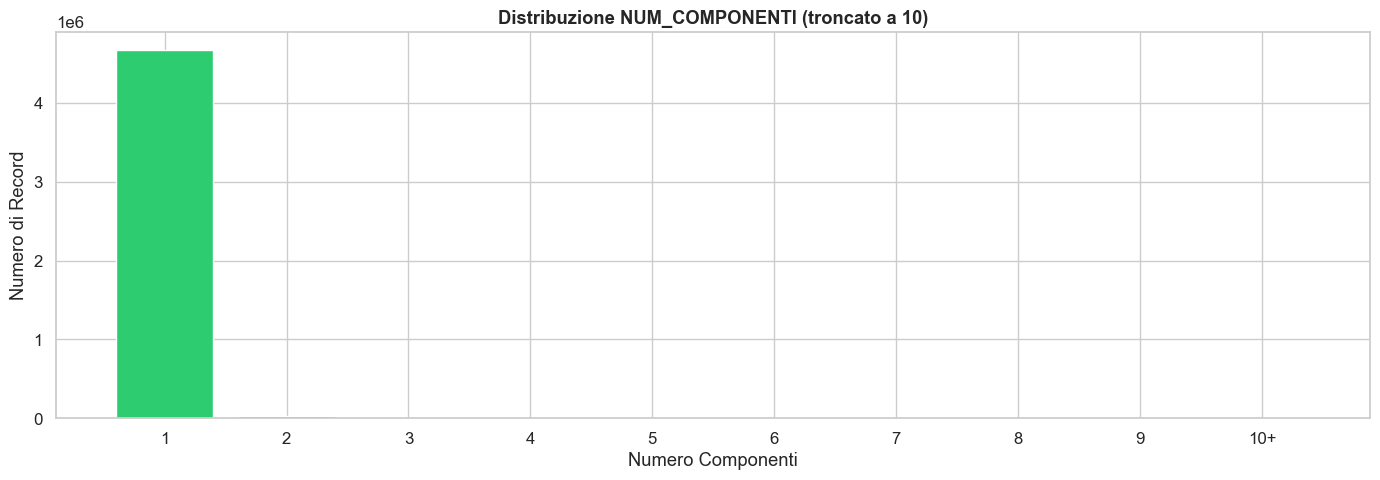

In [27]:
# Progetti multi-beneficiario (NUM_COMPONENTI > 1)
print('=== PROGETTI MULTI-BENEFICIARIO (NUM_COMPONENTI) ===\n')

comp_stats = df['NUM_COMPONENTI'].describe()
print(f'Statistiche NUM_COMPONENTI:')
print(f'  Media:    {comp_stats["mean"]:.2f}')
print(f'  Mediana:  {comp_stats["50%"]:.0f}')
print(f'  Max:      {comp_stats["max"]:.0f}')

multi_comp = df[df['NUM_COMPONENTI'] > 1]
print(f'\nRecord con NUM_COMPONENTI > 1: {len(multi_comp):,} ({len(multi_comp)/len(df)*100:.2f}%)')

fig, ax = plt.subplots(figsize=(14, 5))
comp_dist = df['NUM_COMPONENTI'].clip(upper=10).value_counts().sort_index()
ax.bar(comp_dist.index, comp_dist.values, color='#2ecc71', edgecolor='white')
ax.set_xlabel('Numero Componenti')
ax.set_ylabel('Numero di Record')
ax.set_title('Distribuzione NUM_COMPONENTI (troncato a 10)', fontweight='bold')
ax.set_xticks(range(1, 11))
ax.set_xticklabels([str(i) if i < 10 else '10+' for i in range(1, 11)])
plt.tight_layout()
plt.show()

## 9. Strumenti di Aiuto e Obiettivi

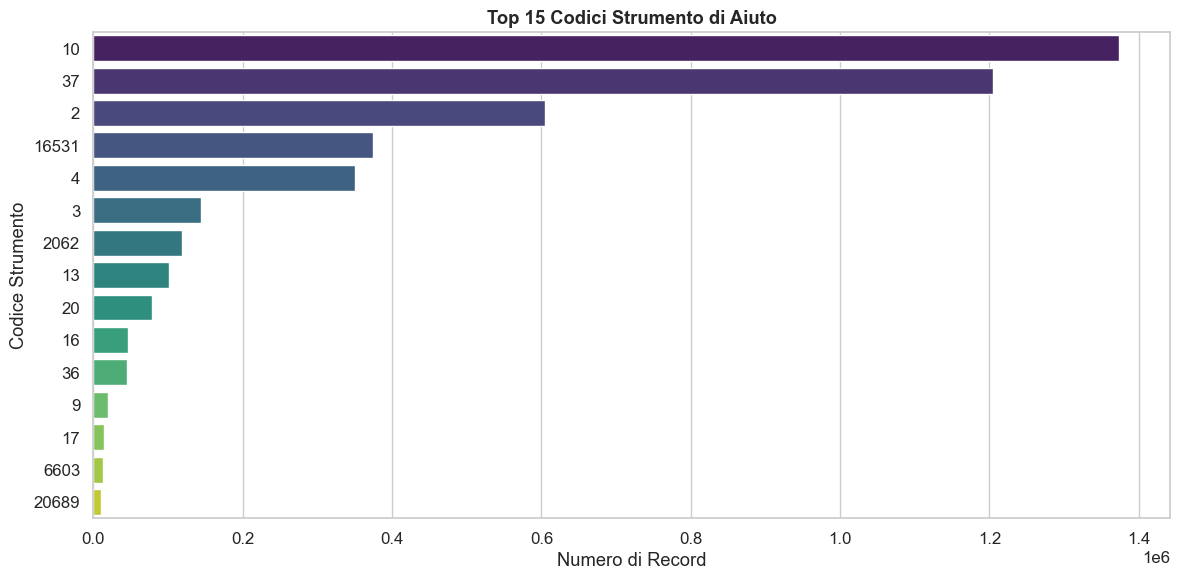


Riferimento codici strumento (RNA):
  1 = Sovvenzione/Contributo a fondo perduto
  2 = Prestito agevolato
  3 = Garanzia
  4 = Agevolazione fiscale
  5 = Conferimento di capitale
  6 = Anticipo rimborsabile


In [28]:
# Distribuzione codici strumenti
strumenti_counts = df['COD_STRUMENTI'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=strumenti_counts.values, y=strumenti_counts.index.astype(str), palette='viridis', ax=ax)
ax.set_title('Top 15 Codici Strumento di Aiuto', fontweight='bold')
ax.set_xlabel('Numero di Record')
ax.set_ylabel('Codice Strumento')
plt.tight_layout()
plt.show()

print('\nRiferimento codici strumento (RNA):')
print('  1 = Sovvenzione/Contributo a fondo perduto')
print('  2 = Prestito agevolato')
print('  3 = Garanzia')
print('  4 = Agevolazione fiscale')
print('  5 = Conferimento di capitale')
print('  6 = Anticipo rimborsabile')

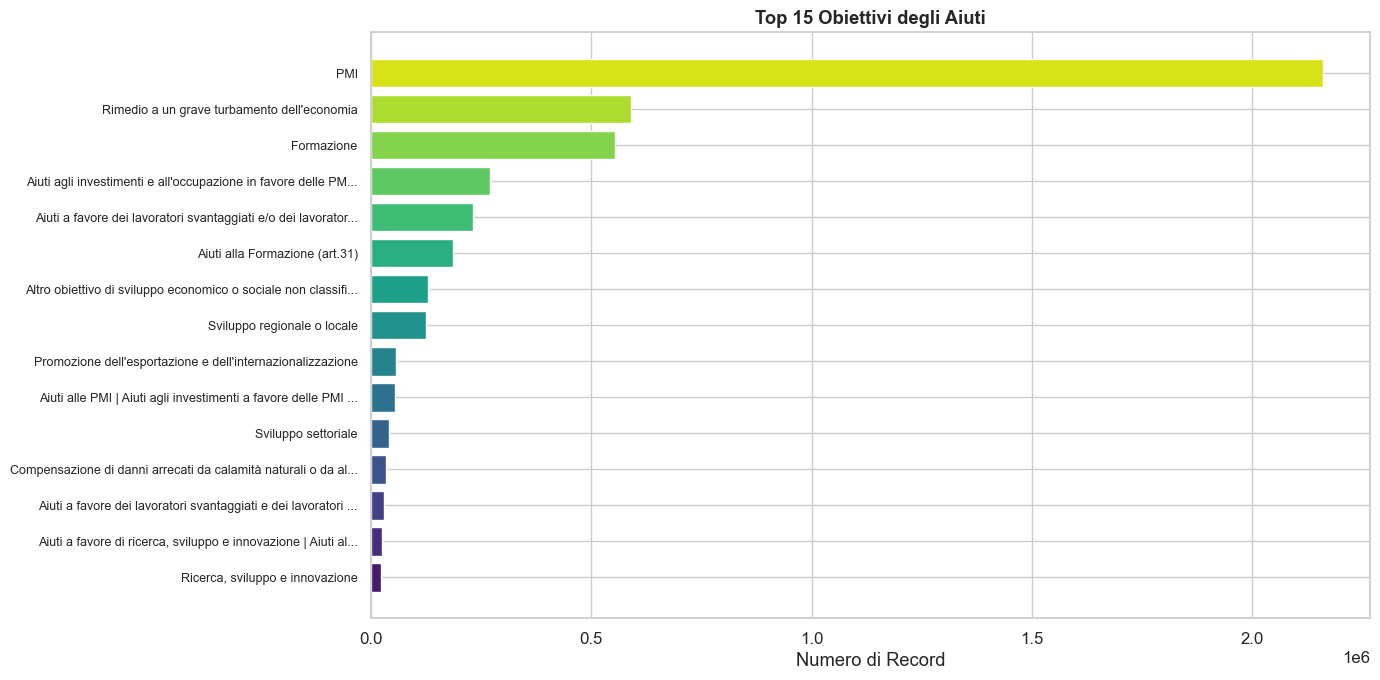

In [29]:
# Distribuzione obiettivi
obiettivo_counts = df['OBIETTIVO'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(14, 7))
obj_sorted = obiettivo_counts.sort_values(ascending=True)
ax.barh(range(len(obj_sorted)), obj_sorted.values,
        color=sns.color_palette('viridis', len(obj_sorted)))
ax.set_yticks(range(len(obj_sorted)))
ax.set_yticklabels([t[:60] + '...' if len(str(t)) > 60 else t for t in obj_sorted.index], fontsize=9)
ax.set_xlabel('Numero di Record')
ax.set_title('Top 15 Obiettivi degli Aiuti', fontweight='bold')
plt.tight_layout()
plt.show()

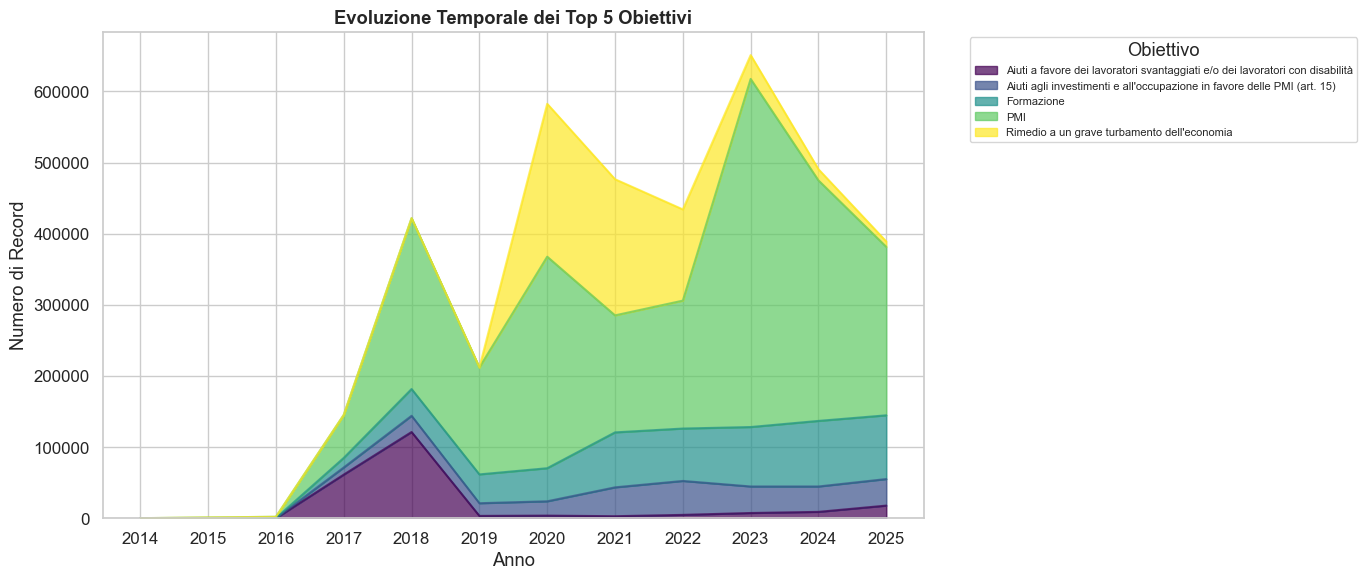

In [30]:
# Evoluzione temporale degli obiettivi principali
top_obiettivi = df['OBIETTIVO'].value_counts().head(5).index.tolist()
obj_anno = df[df['OBIETTIVO'].isin(top_obiettivi)].groupby(['ANNO', 'OBIETTIVO']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
obj_anno.plot(kind='area', stacked=True, ax=ax, alpha=0.7, colormap='viridis')
ax.set_title('Evoluzione Temporale dei Top 5 Obiettivi', fontweight='bold')
ax.set_xlabel('Anno')
ax.set_ylabel('Numero di Record')
ax.legend(title='Obiettivo', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.set_xticks(YEARS)
plt.tight_layout()
plt.show()

## 10. Tipo di Misura e Top Misure

Distribuzione DES_TIPO_MISURA:
  Regime di aiuti                   4,695,112 (99.9%)
  Aiuto ad hoc                          6,202 (0.1%)


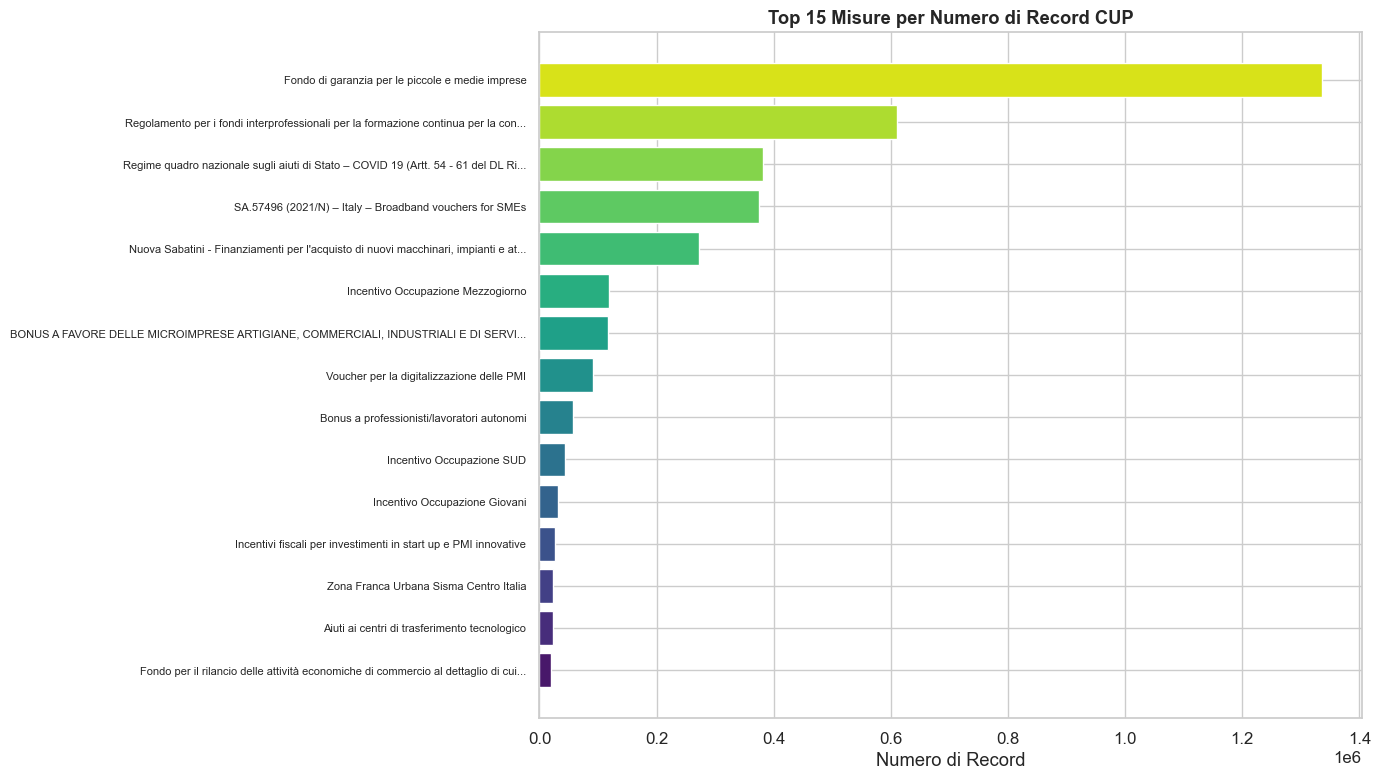

In [31]:
# Distribuzione tipo misura
tipo_misura = df['DES_TIPO_MISURA'].value_counts()
print('Distribuzione DES_TIPO_MISURA:')
for tipo, count in tipo_misura.items():
    print(f'  {tipo:30s} {count:>12,} ({count/len(df)*100:.1f}%)')

# Top 15 misure per numero di record
top_misure = df['TITOLO_MISURA'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(14, 8))
top_misure_sorted = top_misure.sort_values(ascending=True)
ax.barh(range(len(top_misure_sorted)), top_misure_sorted.values,
        color=sns.color_palette('viridis', len(top_misure_sorted)))
ax.set_yticks(range(len(top_misure_sorted)))
ax.set_yticklabels([t[:80] + '...' if len(str(t)) > 80 else t for t in top_misure_sorted.index], fontsize=8)
ax.set_xlabel('Numero di Record')
ax.set_title('Top 15 Misure per Numero di Record CUP', fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Heatmap Settore × Regione

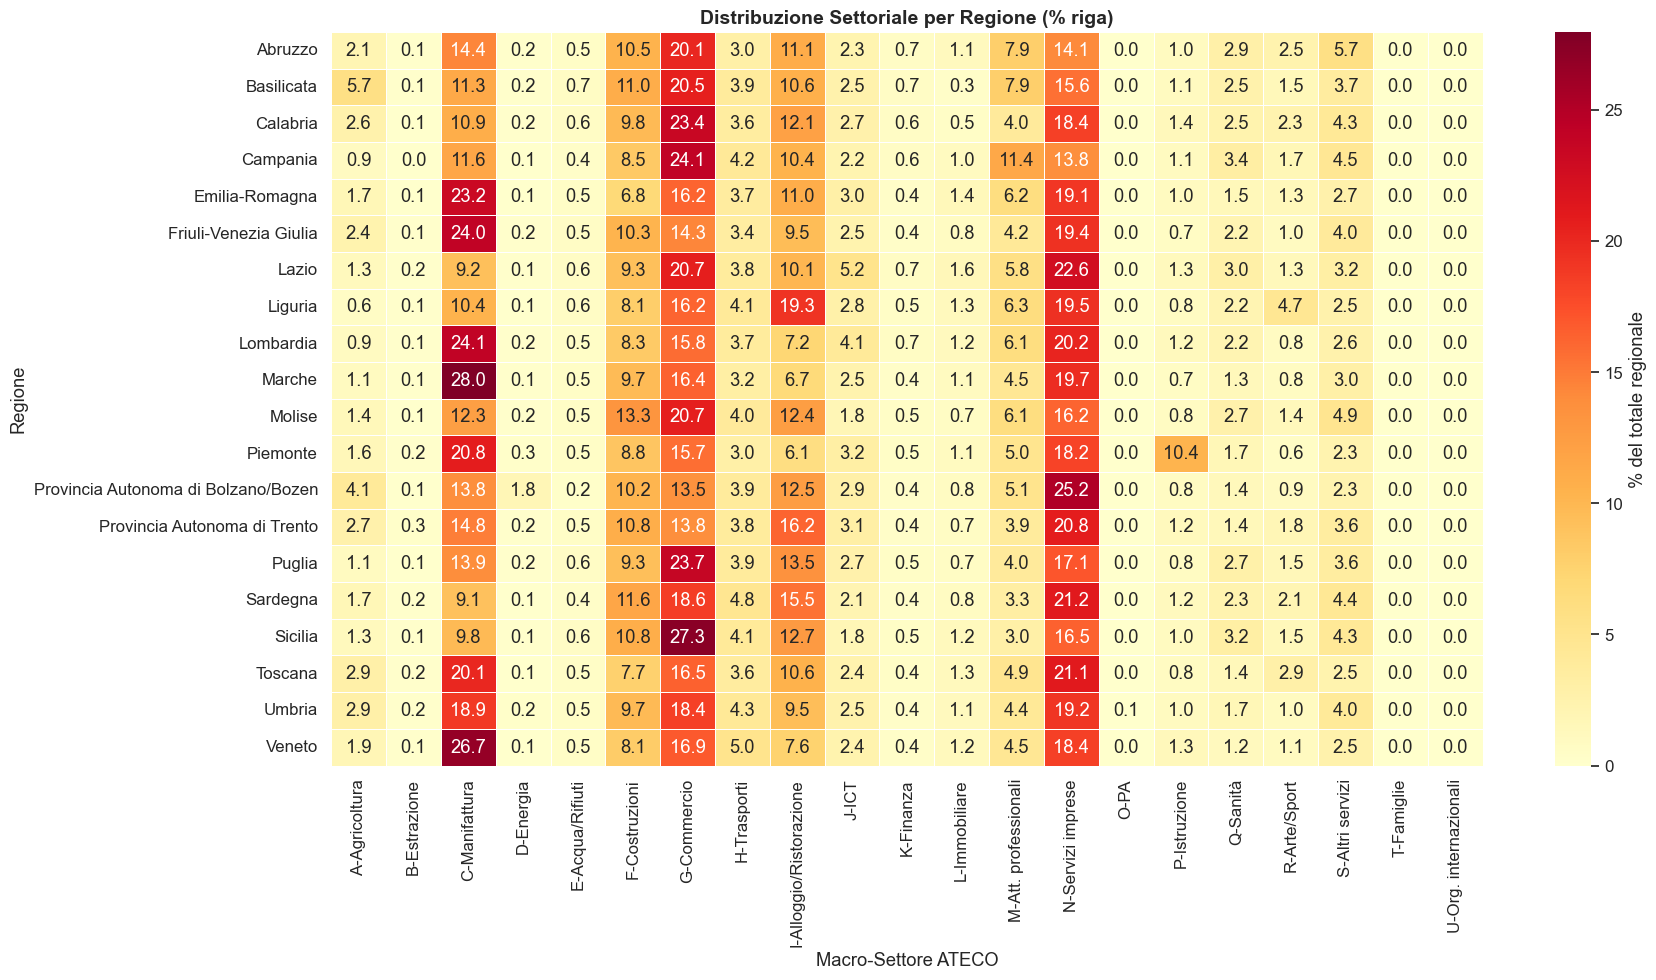

In [32]:
# Heatmap: Macro-settore ATECO × Regione (solo regioni italiane standard)
df_it = df[df['REGIONE_BENEFICIARIO'].isin(regioni_italiane)].copy()

cross = pd.crosstab(df_it['REGIONE_BENEFICIARIO'], df_it['SETTORE_MACRO'])
# Rinomina colonne con nomi leggibili
cross.columns = [f'{s}-{ateco_map.get(s, "?")}' for s in cross.columns]

# Normalizza per riga (percentuale per regione)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(18, 10))
sns.heatmap(cross_pct, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, linewidths=0.5,
            cbar_kws={'label': '% del totale regionale'})
ax.set_title('Distribuzione Settoriale per Regione (% riga)', fontweight='bold', fontsize=14)
ax.set_xlabel('Macro-Settore ATECO')
ax.set_ylabel('Regione')
plt.tight_layout()
plt.show()

## 12. Pulizia Dati per Compatibilità STATA

Sulla base delle verifiche di consistenza (sezione 3), applichiamo le seguenti correzioni:

1. **Date**: rimozione suffisso timezone da `DATA_CONCESSIONE`
2. **Campi multi-valore**: sostituzione separatore `,` → `|` in `REGIONE_BENEFICIARIO` e `SETTORI_ATTIVITA` (dove la virgola separa valori distinti)
3. **A-capo nei testi**: rimozione di `\r\n` e `\n` da campi testuali
4. **Doppi apici interni**: normalizzazione nei campi di testo

> **Nota**: `OBIETTIVO` usa già `|` come separatore multi-valore — le virgole al suo interno fanno parte del testo naturale (es. "Ricerca, sviluppo e innovazione") e non vengono modificate. Analogamente, le virgole in `DENOMINAZIONE_BENEFICIARIO` sono parte delle ragioni sociali.

In [33]:
import re

df_clean = df.copy()
print('=== PULIZIA DATI PER STATA ===\n')

# --- 1. Rimozione timezone da DATA_CONCESSIONE ---
# "2014-06-30+02:00" → "2014-06-30"
n_tz_before = df_clean['DATA_CONCESSIONE'].str.contains(r'[+-]\d{2}:\d{2}$', regex=True, na=False).sum()
df_clean['DATA_CONCESSIONE'] = df_clean['DATA_CONCESSIONE'].str.replace(
    r'[+-]\d{2}:\d{2}$', '', regex=True
)
n_tz_after = df_clean['DATA_CONCESSIONE'].str.contains(r'[+-]\d{2}:\d{2}$', regex=True, na=False).sum()
print(f'1. Timezone rimosso da DATA_CONCESSIONE: {n_tz_before:,} record corretti (residui: {n_tz_after})')
print(f'   Esempio: "{df_clean["DATA_CONCESSIONE"].dropna().iloc[0]}"')

# --- 2. Campi multi-valore: virgola → pipe + deduplicazione ---
# REGIONE_BENEFICIARIO: "Lazio, Marche" → "Lazio|Marche"
# SETTORI_ATTIVITA: "G.47.6, G.47.7" → "G.47.6|G.47.7"
multi_val_cols = ['REGIONE_BENEFICIARIO', 'SETTORI_ATTIVITA']
for col in multi_val_cols:
    n_with_comma = df_clean[col].str.contains(',', na=False).sum()
    # Sostituisci anche eventuali pipe già presenti nel dato originale
    df_clean[col] = df_clean[col].str.replace(', ', '|', regex=False)
    
    # Deduplicazione: rimuovi valori ripetuti mantenendo l'ordine
    mask = df_clean[col].notna()
    n_before_dedup = df_clean.loc[mask, col].apply(
        lambda x: len(x.split('|')) != len(set(x.split('|')))
    ).sum()
    df_clean.loc[mask, col] = df_clean.loc[mask, col].apply(
        lambda x: '|'.join(dict.fromkeys(x.split('|')))
    )
    
    n_after = df_clean[col].str.contains(',', na=False).sum()
    print(f'\n2. {col}: virgola → pipe + deduplicazione')
    print(f'   Record con virgola prima: {n_with_comma:,} → dopo: {n_after:,}')
    print(f'   Record con valori duplicati rimossi: {n_before_dedup:,}')
    # Mostra esempio
    sample = df_clean[df_clean[col].str.contains(r'\|', na=False)][col].head(1)
    if len(sample) > 0:
        print(f'   Esempio: "{sample.iloc[0]}"')

# --- 3. Rimozione a-capo nei campi testuali ---
text_cols = ['TITOLO_PROGETTO', 'DESCRIZIONE_PROGETTO', 'TITOLO_MISURA', 'DENOMINAZIONE_BENEFICIARIO']
print(f'\n3. Rimozione a-capo (\\r\\n, \\n) dai campi testuali:')
for col in text_cols:
    n_newlines = df_clean[col].str.contains(r'[\r\n]', regex=True, na=False).sum()
    if n_newlines > 0:
        df_clean[col] = df_clean[col].str.replace(r'\r\n', ' ', regex=True)
        df_clean[col] = df_clean[col].str.replace(r'\n', ' ', regex=True)
        print(f'   {col}: {n_newlines:,} record ripuliti')
    else:
        print(f'   {col}: nessun a-capo trovato')

# --- 4. Normalizzazione doppi apici interni ---
# Sostituisce " interne con ' per evitare problemi di parsing CSV
print(f'\n4. Normalizzazione doppi apici interni:')
for col in text_cols:
    n_quotes = df_clean[col].str.contains('"', na=False).sum()
    if n_quotes > 0:
        df_clean[col] = df_clean[col].str.replace('"', "'", regex=False)
        print(f'   {col}: {n_quotes:,} record con doppi apici → sostituiti con apice singolo')
    else:
        print(f'   {col}: nessun doppio apice trovato')

# --- Verifica finale ---
print(f'\n{"="*60}')
print(f'✅ Pulizia completata su {len(df_clean):,} record')
print(f'   Colonne nel dataset: {len(df_clean.columns)}')
print(f'   Shape: {df_clean.shape}')

=== PULIZIA DATI PER STATA ===

1. Timezone rimosso da DATA_CONCESSIONE: 3,526,814 record corretti (residui: 0)
   Esempio: "2014-06-30"

2. REGIONE_BENEFICIARIO: virgola → pipe + deduplicazione
   Record con virgola prima: 22,870 → dopo: 0
   Record con valori duplicati rimossi: 0
   Esempio: "Emilia-Romagna|Provincia Autonoma di Trento"

2. SETTORI_ATTIVITA: virgola → pipe + deduplicazione
   Record con virgola prima: 28,143 → dopo: 0
   Record con valori duplicati rimossi: 64
   Esempio: "M.74.0|M.75.0"

3. Rimozione a-capo (\r\n, \n) dai campi testuali:
   TITOLO_PROGETTO: 21,221 record ripuliti
   DESCRIZIONE_PROGETTO: 138,233 record ripuliti
   TITOLO_MISURA: nessun a-capo trovato
   DENOMINAZIONE_BENEFICIARIO: 217 record ripuliti

4. Normalizzazione doppi apici interni:
   TITOLO_PROGETTO: 49,899 record con doppi apici → sostituiti con apice singolo
   DESCRIZIONE_PROGETTO: 207,760 record con doppi apici → sostituiti con apice singolo
   TITOLO_MISURA: 181,198 record con doppi a

## 13. Esportazione Dataset Pulito

Salvataggio dei dati ripuliti in `data/cup_clean/`:
- Un file per anno (`cup_clean_YYYY.csv`)
- Un file unico con tutti i record (`cup_clean_all.csv`)

In [34]:
from pathlib import Path

output_dir = Path('../data/cup_clean')
output_dir.mkdir(parents=True, exist_ok=True)

print(f'=== ESPORTAZIONE DATASET PULITO ===\n')
print(f'Directory di output: {output_dir.resolve()}\n')

# Salvataggio per anno
total_rows = 0
for anno in sorted(df_clean['ANNO'].unique()):
    df_anno = df_clean[df_clean['ANNO'] == anno]
    filename = f'cup_clean_{anno}.csv'
    filepath = output_dir / filename
    df_anno.to_csv(filepath, index=False, encoding='utf-8')
    size_mb = filepath.stat().st_size / (1024 * 1024)
    total_rows += len(df_anno)
    print(f'  ✅ {filename:25s} | {len(df_anno):>10,} righe | {size_mb:>7.1f} MB')

# Salvataggio file unico
all_path = output_dir / 'cup_clean_all.csv'
df_clean.to_csv(all_path, index=False, encoding='utf-8')
all_size_mb = all_path.stat().st_size / (1024 * 1024)

print(f'\n  ✅ {"cup_clean_all.csv":25s} | {len(df_clean):>10,} righe | {all_size_mb:>7.1f} MB')
print(f'\n{"="*60}')
print(f'📁 Totale: {total_rows:,} righe esportate in {len(df_clean["ANNO"].unique())} file annuali + 1 file aggregato')
print(f'   Directory: {output_dir.resolve()}')

=== ESPORTAZIONE DATASET PULITO ===

Directory di output: /Users/gabrielevianello/Documents/Università/UnivPM/Paper/Organizzazione dell'Impresa/open-data-analytics/data/cup_clean

  ✅ cup_clean_2014.csv        |     15,434 righe |     8.5 MB
  ✅ cup_clean_2015.csv        |      2,106 righe |     1.0 MB
  ✅ cup_clean_2016.csv        |      8,132 righe |     3.4 MB
  ✅ cup_clean_2017.csv        |    181,968 righe |    81.8 MB
  ✅ cup_clean_2018.csv        |    525,825 righe |   270.4 MB
  ✅ cup_clean_2019.csv        |    284,698 righe |   115.1 MB
  ✅ cup_clean_2020.csv        |    654,762 righe |   281.6 MB
  ✅ cup_clean_2021.csv        |    573,143 righe |   271.5 MB
  ✅ cup_clean_2022.csv        |    522,647 righe |   245.7 MB
  ✅ cup_clean_2023.csv        |    768,756 righe |   320.3 MB
  ✅ cup_clean_2024.csv        |    597,320 righe |   258.5 MB
  ✅ cup_clean_2025.csv        |    566,523 righe |   263.6 MB

  ✅ cup_clean_all.csv         |  4,701,314 righe |  2121.4 MB

📁 Totale: 4

## 14. Riepilogo

In questo notebook abbiamo esplorato i dati aggregati per CUP degli aiuti di stato italiani:

- **Profiling**: struttura, tipi, valori mancanti e dimensioni del dataset
- **Consistenza STATA**: verifiche su nomi colonne, lunghezza stringhe, encoding, formato date, delimitatori interni, valori numerici e formato CUP — con raccomandazioni operative per l'import
- **Analisi finanziaria**: distribuzione importi (totali, medi, mediani), evoluzione temporale
- **Distribuzione geografica**: record e importi per regione, gestione valori multi-regione
- **Analisi settoriale**: distribuzione ATECO, importo medio per settore, heatmap settore × regione
- **Beneficiari**: tipologia (PMI vs grandi imprese), top beneficiari per volume e importo
- **CUP**: unicità, duplicati, progetti multi-anno e multi-beneficiario
- **Strumenti e obiettivi**: codici strumento, evoluzione temporale degli obiettivi, top misure
- **Pulizia dati**: rimozione timezone, normalizzazione separatori multi-valore (virgola → pipe), rimozione a-capo e doppi apici nei campi testuali
- **Esportazione**: dataset pulito salvato in `data/cup_clean/` (file annuali + file unico)